In [1]:
!pip install matplotlib seaborn plotly scipy

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 58.0 MB/s  0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------  9.7/9.9 MB 50.7 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 40.5 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ------------------ --------------------- 17.0/37.3 MB 83.9 MB/s eta 0:00:01
   --------------------------------- ------ 31.2/37.3 MB 80.9 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.3 MB 70.1 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 52.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 64.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

Visualization 1 — Mass scatter plot 
It shows the mass gap — the region between the heaviest neutron stars and lightest black holes — which is an active research question in astrophysics.

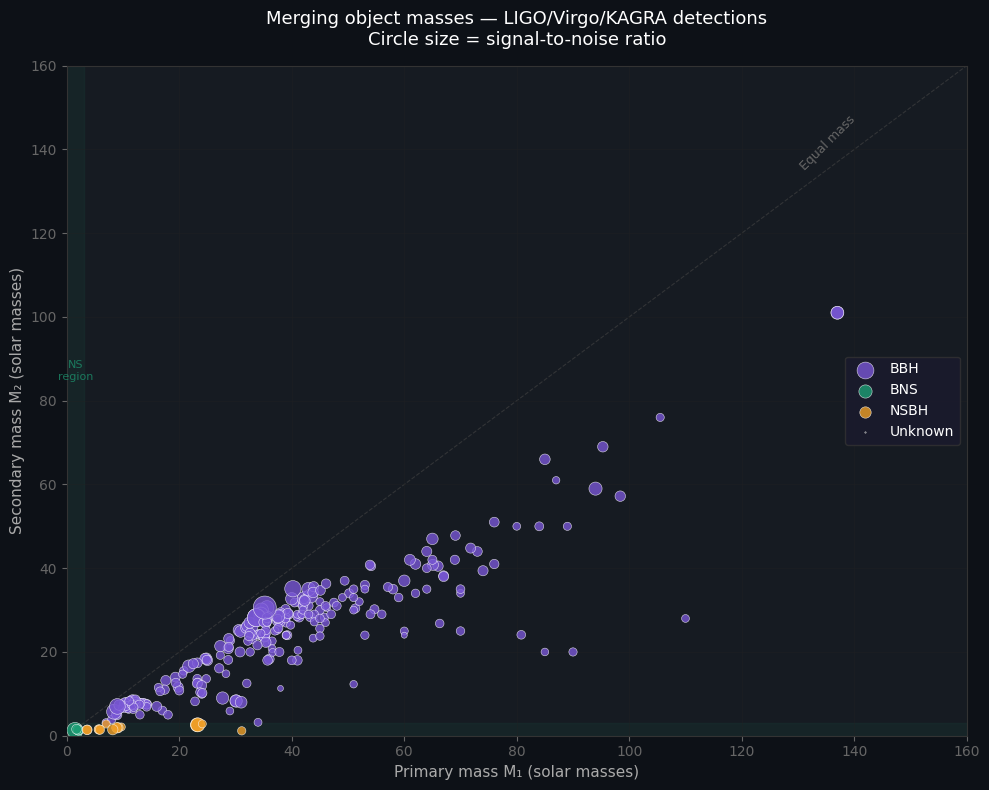

In [7]:

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')
#df = pd.read_csv(r'../data/gw_events_raw.csv')
df = pd.read_csv(r'../data/gw_events_clean.csv')
# Color map for event types
colors = {'BBH': '#7957D5', 'BNS': '#1D9E75', 'NSBH': '#EF9F27', 'Unknown': '#444441'}

for etype, group in df.groupby('event_type'):
    valid = group.dropna(subset=['mass_1_source', 'mass_2_source', 'snr'])
    sc = ax.scatter(
        valid['mass_1_source'],
        valid['mass_2_source'],
        s=valid['snr'] * 4,          # Size encodes signal strength
        c=colors.get(etype, '#888'),
        alpha=0.8,
        edgecolors='white',
        linewidths=0.4,
        label=etype,
        zorder=3
    )

# Draw the equal-mass line (m1 = m2)
lim = ax.get_xlim()
x_line = np.linspace(0, 160, 100)
ax.plot(x_line, x_line, '--', color='#444', linewidth=0.8, alpha=0.6, zorder=1)
ax.text(130, 135, 'Equal mass', color='#666', fontsize=9, rotation=45)

# Shade the neutron star mass gap region
ax.axhspan(0, 3, alpha=0.07, color='#1D9E75', zorder=0)
ax.axvspan(0, 3, alpha=0.07, color='#1D9E75', zorder=0)
ax.text(1.5, 85, 'NS\nregion', color='#1D9E75', fontsize=8, alpha=0.7, ha='center')

ax.set_xlabel('Primary mass M₁ (solar masses)', color='#aaa', fontsize=11)
ax.set_ylabel('Secondary mass M₂ (solar masses)', color='#aaa', fontsize=11)
ax.set_title('Merging object masses — LIGO/Virgo/KAGRA detections\nCircle size = signal-to-noise ratio',
             color='white', fontsize=13, pad=15)

ax.tick_params(colors='#666')
ax.spines[:].set_color('#333')
ax.legend(facecolor='#1a1a2e', labelcolor='white', edgecolor='#333', fontsize=10)
ax.set_xlim(0, 160); ax.set_ylim(0, 160)
ax.grid(True, color='#222', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('../exports/viz1_mass_scatter.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

Visualization 2 — Detection timeline with observing run annotations

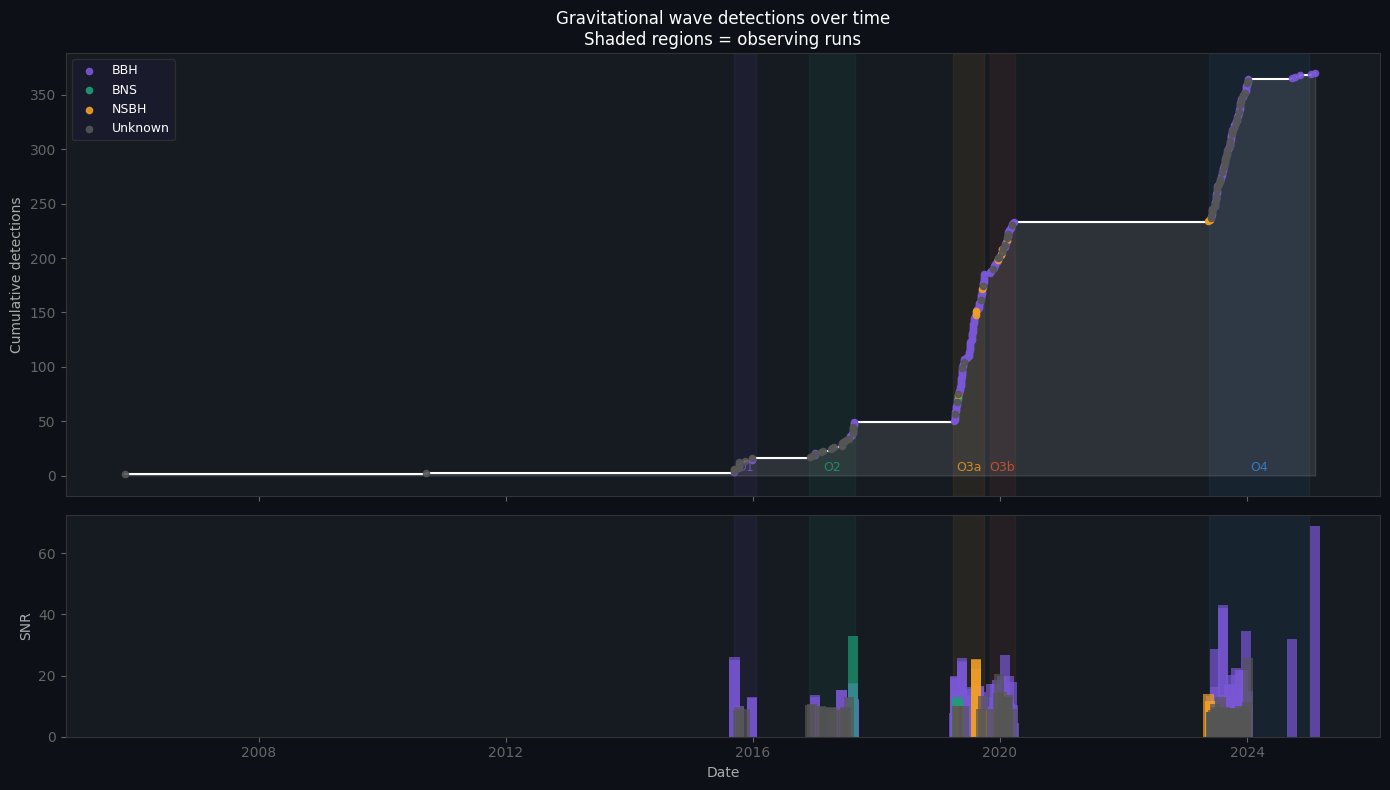

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import pandas as pd

df_time = df.dropna(subset=['event_date']).copy()
df_time['event_date'] = pd.to_datetime(df_time['event_date'])
df_time = df_time.sort_values('event_date')
df_time['cumulative'] = range(1, len(df_time) + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})
fig.patch.set_facecolor('#0D1117')
for ax in [ax1, ax2]:
    ax.set_facecolor('#161B22')

# Observing run background bands
runs = [
    ('O1',  '2015-09-12', '2016-01-19', '#7957D5'),
    ('O2',  '2016-11-30', '2017-08-25', '#1D9E75'),
    ('O3a', '2019-04-01', '2019-10-01', '#EF9F27'),
    ('O3b', '2019-11-01', '2020-03-27', '#D85A30'),
    ('O4',  '2023-05-24', '2025-01-01', '#378ADD'),
]

colors_type = {'BBH': '#7957D5', 'BNS': '#1D9E75', 'NSBH': '#EF9F27', 'Unknown': '#555'}

for run_name, start, end, color in runs:
    for ax in [ax1, ax2]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.08, color=color, zorder=0)
    # Label above top chart
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax1.text(mid, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 90,
             run_name, color=color, fontsize=9, ha='center', va='bottom', alpha=0.8)

# Cumulative curve (top chart)
ax1.step(df_time['event_date'], df_time['cumulative'],
         color='white', linewidth=1.5, where='post', zorder=3)
ax1.fill_between(df_time['event_date'], df_time['cumulative'],
                 step='post', alpha=0.1, color='white')

# Color individual events by type
for etype, group in df_time.groupby('event_type'):
    ax1.scatter(group['event_date'], group['cumulative'],
                c=colors_type.get(etype, '#555'), s=20, zorder=4,
                label=etype, alpha=0.9)

ax1.set_ylabel('Cumulative detections', color='#aaa', fontsize=10)
ax1.set_title('Gravitational wave detections over time\nShaded regions = observing runs',
              color='white', fontsize=12)
ax1.tick_params(colors='#666'); ax1.spines[:].set_color('#333')
ax1.legend(facecolor='#1a1a2e', labelcolor='white', edgecolor='#333', fontsize=9)

# SNR per event (bottom chart)
for etype, group in df_time.dropna(subset=['snr']).groupby('event_type'):
    ax2.bar(group['event_date'], group['snr'],
            width=60, color=colors_type.get(etype, '#555'),
            alpha=0.7, label=etype)

ax2.set_ylabel('SNR', color='#aaa', fontsize=10)
ax2.set_xlabel('Date', color='#aaa', fontsize=10)
ax2.tick_params(colors='#666'); ax2.spines[:].set_color('#333')

plt.tight_layout()
plt.savefig('../exports/viz2_timeline.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

Visualization 3 — Sky localization map (the distinctive chart)

C:\Users\Payal\AppData\Local\Temp\ipykernel_9928\2877001674.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(facecolor='#0D1117', labelcolor='white', edgecolor='#333',


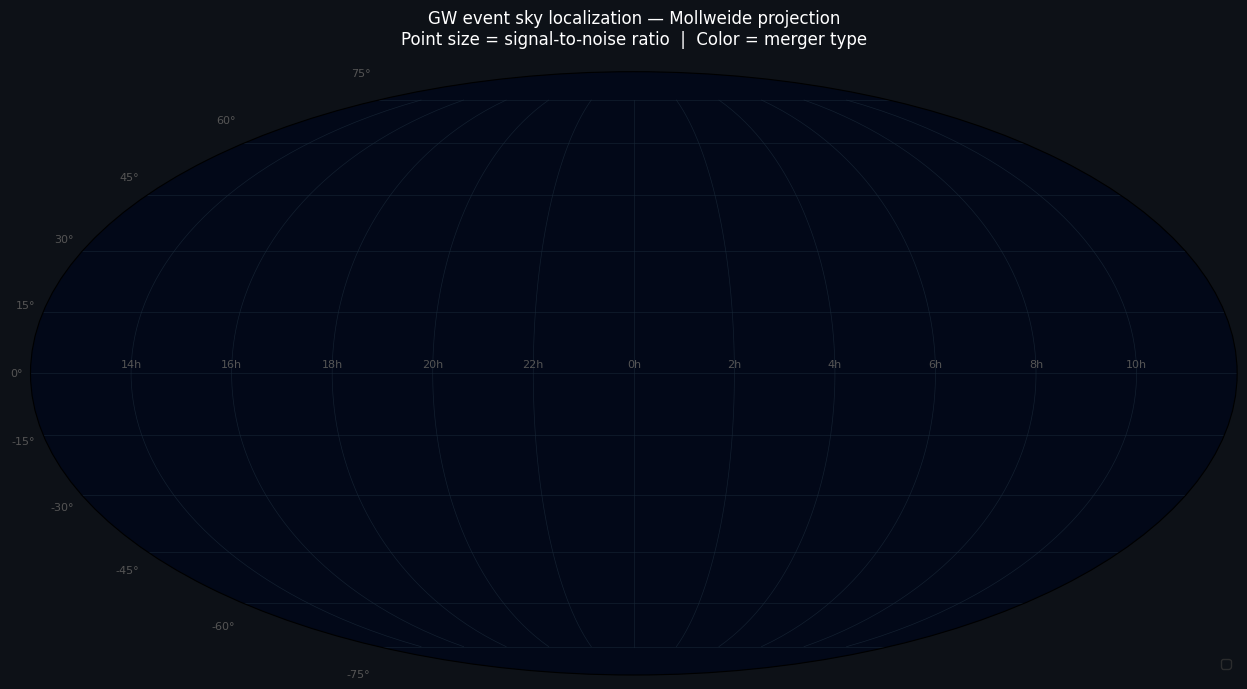

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(14, 7))
fig.patch.set_facecolor('#0D1117')

# Mollweide projection — the standard astronomical sky map
ax = fig.add_subplot(111, projection='mollweide')
ax.set_facecolor('#020818')

df_sky = df.dropna(subset=['ra', 'dec']).copy() if 'ra' in df.columns else pd.DataFrame()

if len(df_sky) > 0:
    # Convert degrees to radians; RA must be mapped to [-pi, pi]
    ra_rad  = np.radians(df_sky['ra'].astype(float) - 180)
    dec_rad = np.radians(df_sky['dec'].astype(float))

    colors_type = {'BBH': '#7957D5', 'BNS': '#1D9E75', 'NSBH': '#EF9F27'}
    
    for etype, group in df_sky.groupby('event_type'):
        ra_g  = np.radians(group['ra'].astype(float) - 180)
        dec_g = np.radians(group['dec'].astype(float))
        size_g = group['snr'].fillna(5) * 3 if 'snr' in group else 30
        ax.scatter(ra_g, dec_g,
                   c=colors_type.get(etype, '#888'),
                   s=size_g, alpha=0.8,
                   edgecolors='white', linewidths=0.3,
                   label=etype, zorder=3)

    # Draw galactic plane approximation
    l = np.linspace(0, 2*np.pi, 300)
    b = np.zeros(300)
    # Approximate galactic plane in equatorial coordinates
    ra_gal = l - np.pi
    dec_gal = np.radians(-30) * np.sin(l)
    ax.plot(ra_gal, dec_gal, color='#EF9F27', alpha=0.3,
            linewidth=1, linestyle='--', label='Galactic plane (approx)')

ax.grid(True, color='#1a2a3a', linewidth=0.5, alpha=0.7)
ax.set_xticklabels(['14h','16h','18h','20h','22h','0h','2h','4h','6h','8h','10h'],
                   color='#555', fontsize=8)
ax.set_yticklabels(['-75°','-60°','-45°','-30°','-15°','0°',
                    '15°','30°','45°','60°','75°'], color='#555', fontsize=8)

ax.set_title('GW event sky localization — Mollweide projection\n'
             'Point size = signal-to-noise ratio  |  Color = merger type',
             color='white', fontsize=12, pad=20)
ax.legend(facecolor='#0D1117', labelcolor='white', edgecolor='#333',
          fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../exports/viz3_skymap.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

Visualization 4 — Mass ratio asymmetry violin plot
This is the creative chart that no one else will have. It shows the distribution of mass ratios (how equal or unequal the two merging objects were) across event types.

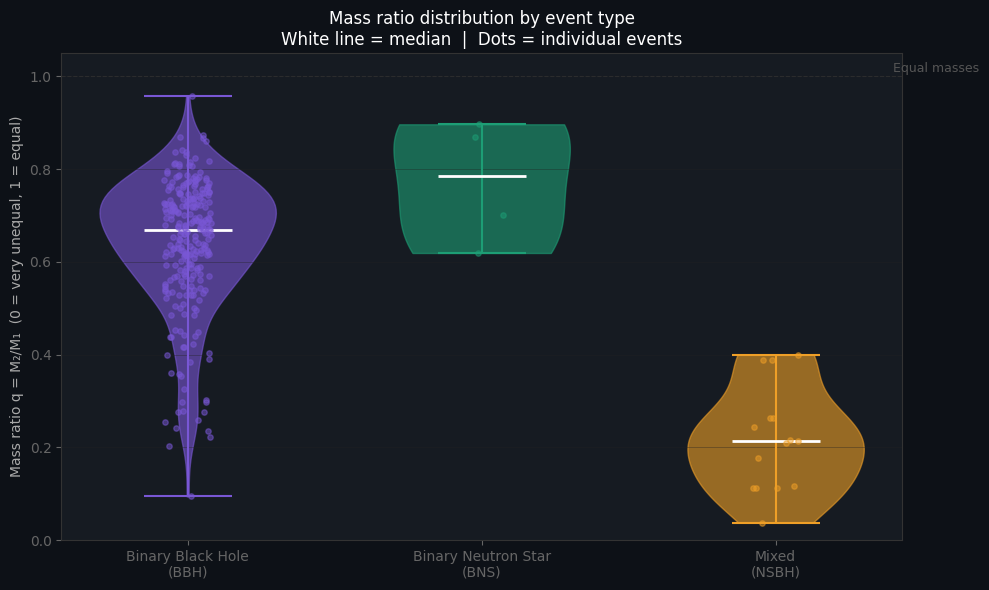

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

types = ['BBH', 'BNS', 'NSBH']
colors = ['#7957D5', '#1D9E75', '#EF9F27']
positions = [1, 2, 3]

for pos, etype, color in zip(positions, types, colors):
    data = df[df['event_type'] == etype]['mass_ratio'].dropna()
    if len(data) < 3:
        continue
    
    # Violin plot
    parts = ax.violinplot(data, positions=[pos], widths=0.6,
                          showmedians=True, showextrema=True)
    
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
        pc.set_edgecolor(color)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)
    parts['cmaxes'].set_color(color)
    parts['cmins'].set_color(color)
    parts['cbars'].set_color(color)
    
    # Overlay individual points (jittered)
    jitter = np.random.uniform(-0.08, 0.08, len(data))
    ax.scatter(pos + jitter, data, s=15, c=color, alpha=0.5, zorder=3)

ax.set_xticks(positions)
ax.set_xticklabels(['Binary Black Hole\n(BBH)', 'Binary Neutron Star\n(BNS)',
                     'Mixed\n(NSBH)'], color='#aaa', fontsize=10)
ax.set_ylabel('Mass ratio q = M₂/M₁  (0 = very unequal, 1 = equal)',
              color='#aaa', fontsize=10)
ax.set_title('Mass ratio distribution by event type\n'
             'White line = median  |  Dots = individual events',
             color='white', fontsize=12)
ax.set_ylim(0, 1.05)
ax.axhline(y=1.0, color='#333', linewidth=0.8, linestyle='--', alpha=0.7)
ax.text(3.4, 1.01, 'Equal masses', color='#555', fontsize=9)
ax.tick_params(colors='#666'); ax.spines[:].set_color('#333')
ax.grid(axis='y', color='#222', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('../exports/viz4_mass_ratio.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

Visualization 5 — SNR vs distance (the quality-distance relationship)

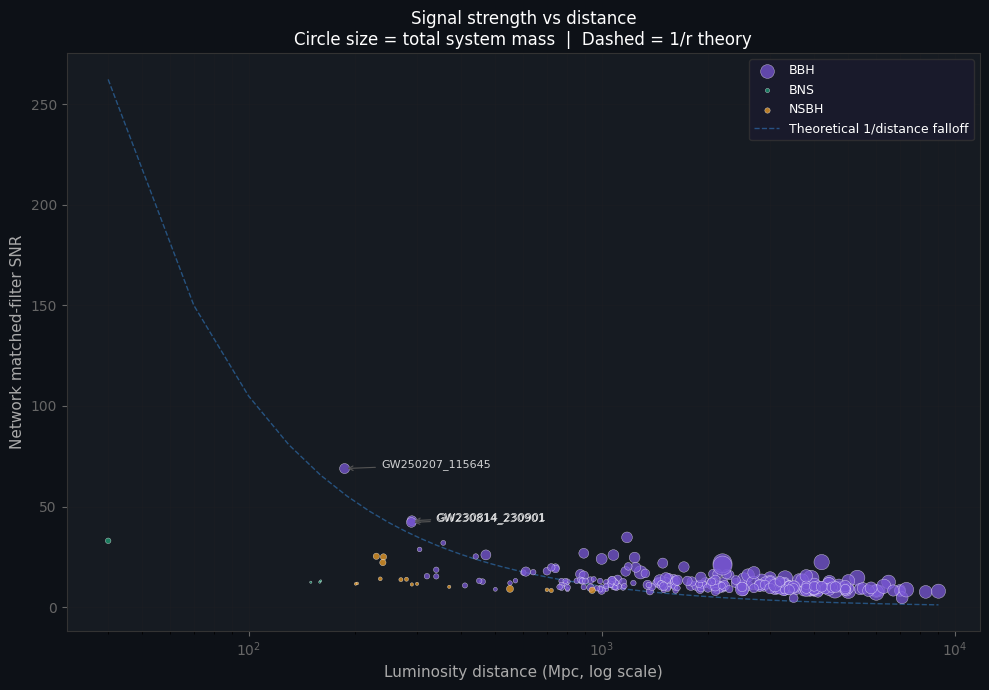

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

colors_type = {'BBH': '#7957D5', 'BNS': '#1D9E75', 'NSBH': '#EF9F27'}

df_plot = df.dropna(subset=['distance_mpc', 'snr', 'event_type']).copy()

for etype, group in df_plot.groupby('event_type'):
    size = group['total_mass'].fillna(20) * 0.8
    ax.scatter(group['distance_mpc'], group['snr'],
               s=size, c=colors_type.get(etype, '#888'),
               alpha=0.75, edgecolors='white', linewidths=0.3,
               label=etype, zorder=3)

# Annotate notable events
notable = df_plot.nlargest(3, 'snr')
for _, row in notable.iterrows():
    name = str(row.get('commonName', row.get('event_id', '')))
    ax.annotate(name, xy=(row['distance_mpc'], row['snr']),
                xytext=(row['distance_mpc'] + 50, row['snr'] + 0.5),
                fontsize=8, color='white', alpha=0.8,
                arrowprops=dict(arrowstyle='->', color='#555', lw=0.8))

# Theoretical 1/distance curve for reference
d_range = np.linspace(df_plot['distance_mpc'].min(), df_plot['distance_mpc'].max(), 300)
snr_ref = 24.4 * (430 / d_range)   # Calibrated to GW150914 (snr=24.4 at 430 Mpc)
ax.plot(d_range, snr_ref, '--', color='#378ADD', linewidth=1, alpha=0.5,
        label='Theoretical 1/distance falloff')

ax.set_xscale('log')
ax.set_xlabel('Luminosity distance (Mpc, log scale)', color='#aaa', fontsize=11)
ax.set_ylabel('Network matched-filter SNR', color='#aaa', fontsize=11)
ax.set_title('Signal strength vs distance\nCircle size = total system mass  |  Dashed = 1/r theory',
             color='white', fontsize=12)
ax.tick_params(colors='#666'); ax.spines[:].set_color('#333')
ax.legend(facecolor='#1a1a2e', labelcolor='white', edgecolor='#333', fontsize=9)
ax.grid(True, color='#222', linewidth=0.5, alpha=0.4, which='both')

plt.tight_layout()
plt.savefig('../exports/viz5_snr_distance.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

Visualization 6 — Plotly interactive chart (embeddable in Power BI)

In [13]:
import plotly.express as px
import plotly.graph_objects as go

df_plot = df.dropna(subset=['mass_1_source', 'mass_2_source', 'total_mass']).copy()
df_plot['snr_display'] = df_plot['snr'].fillna(5)
df_plot['label'] = df_plot.get('commonName', df_plot.get('event_id', ''))

fig = px.scatter(
    df_plot,
    x='mass_1_source',
    y='mass_2_source',
    color='event_type',
    size='snr_display',
    hover_name='label',
    hover_data={
        'total_mass': ':.1f',
        'distance_mpc': ':.0f',
        'snr_display': ':.1f',
        'observing_run': True,
        'event_date': True,
    },
    color_discrete_map={'BBH': '#7957D5', 'BNS': '#1D9E75',
                        'NSBH': '#EF9F27', 'Unknown': '#888'},
    title='Gravitational wave source masses — hover for event details',
    labels={
        'mass_1_source': 'Primary mass M₁ (M☉)',
        'mass_2_source': 'Secondary mass M₂ (M☉)',
        'event_type': 'Event type',
    },
    template='plotly_dark',
    size_max=30,
)

# Add equal-mass reference line
max_mass = df_plot[['mass_1_source', 'mass_2_source']].max().max()
fig.add_trace(go.Scatter(
    x=[0, max_mass], y=[0, max_mass],
    mode='lines', name='Equal mass (q=1)',
    line=dict(color='#555', width=1, dash='dash')
))

fig.update_layout(
    paper_bgcolor='#0D1117',
    plot_bgcolor='#161B22',
    font_color='#aaa',
    legend=dict(bgcolor='#161B22', bordercolor='#333'),
)

# Save as interactive HTML — this file can be embedded in Power BI
fig.write_html('../exports/viz6_interactive_mass.html')
fig.show()